### División de los datos

El dataset se dividió en tres conjuntos 70% entrenamiento, 15% validación y 15% para prueba. Esta distribución permite disponer de una cantidad suficiente de observaciones para entrenar el modelo y al mismo tiempo mantener conjuntos independientes para seleccionar y evaluar la mejor configuración.

- **Entrenamiento (70%):** para ajustar el árbol de decisión y entrenar las diferentes configuraciones de hiperparámetros.
- **Validación (15%):** para comparar las distintas combinaciones de hiperparámetros y seleccionar la configuración con mejor desempeño.
- **Prueba (15%):** Se utiliza únicamente al final para evaluar el desempeño del modelo ganador sobre datos no utilizados previamente.

### Diseño del estudio de hiperparámetros

La selección de los hiperparámetros se realiza con el fin de estudiar de forma controlada algunos de los principales factores que pueden afectar el desempeño del árbol de decisión.

Se evaluarán los siguientes aspectos:

- Profundidad máxima (max_depth): se comparará un árbol sin una profundidad máxima definida frente a un árbol con profundidad limitada. Este hiperparámetro controla la cantidad de niveles que puede desarrollar el árbol. Una profundidad muy alta puede aumentar la capacidad del modelo para ajustarse a los datos de entrenamiento, pero también puede incrementar el riesgo de sobreajuste. Por otro lado, limitar la profundidad puede favorecer una mejor generalización.
- Número mínimo de observaciones por hoja (min_samples_leaf): se comparará un árbol que permita hojas con una sola observación frente a uno que requiera un número mínimo mayor. Aumentar este valor funciona como una forma de regularización, ya que evita que el modelo genere divisiones basadas en grupos muy pequeños de observaciones.
- Criterio de división (criterion): se mantendrá constante el criterio Gini en las tres configuraciones, con el propósito de analizar de forma más controlada el efecto de los demás hiperparámetros.

En síntesis, se estudiarán tres combinaciones representativas. La configuración 1 se utilizará como modelo base sin restricciones importantes sobre el crecimiento del árbol. La configuración 2 modificará únicamente la profundidad máxima, mientras que la configuración 3 modificará únicamente el número mínimo de observaciones por hoja. De esta forma, será posible analizar de manera más clara el efecto de cada cambio sobre el desempeño del modelo.

### Entrenamiento de los modelos

Para realizar el estudio se utilizará DecisionTreeClassifier, que corresponde al algoritmo de árbol de decisión para problemas de clasificación disponible en Scikit-learn.

La selección del mejor modelo se realizará exclusivamente utilizando el conjunto de validación. El conjunto de prueba se reservará para la evaluación final del modelo seleccionado.

Para evaluar el desempeño se utilizarán accuracy, precision, recall, F1 y AUC-ROC. En todas estas métricas, valores mayores representan un mejor desempeño. Además, una vez identificado el modelo ganador, se analizará su matriz de confusión para estudiar con mayor detalle los errores de clasificación.

In [ ]:
# ============================================================
# Preparación de los datos e importe de librerías 
# ============================================================

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# -----------------------------------------------------------
# 1. Cargamos los datos
# -----------------------------------------------------------

df = pd.read_csv("../data/datos_finales.csv")


Dimensiones del dataset:
(48842, 82)


,age,education-num,capital-gain-log,capital-loss-log,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
0,-0.119879,1.136512,-0.297918,-0.221264,-2.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,1.265933,-0.808297,-0.297918,4.450068,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,1.047121,-0.419335,-0.297918,-0.221264,-1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3,2.432933,-1.197259,-0.297918,-0.221264,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,0.536558,1.525474,-0.297918,-0.221264,-0.4,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [6]:
# -----------------------------------------------------------
# 2. Separamos variables predictoras y variable objetivo
# -----------------------------------------------------------

# El archivo datos_finales ya contiene las variables predictoras imputadas, codificadas y escaladas
X_model = df.drop(columns=["income"])

# La variable objetivo ya se encuentra codificada como 0 = <=50K y 1 = >50K
y_model = df["income"]


# -----------------------------------------------------------
# 3. Separación de entrenamiento, validación y prueba
# -----------------------------------------------------------

# Separamos en 70% entrenamiento y 30% temporal para validación y prueba
X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.30,
    random_state=42,
    stratify=y_model
)

# Dividimos el 30% temporal en 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


In [7]:
# -----------------------------------------------------------
# 4. Árbol de Decisión Baseline
# -----------------------------------------------------------

decision_tree_baseline = DecisionTreeClassifier(random_state=42)

# Entrenamiento
decision_tree_baseline.fit(X_train, y_train)

# Predicciones sobre validación
y_pred_tree_baseline = decision_tree_baseline.predict(X_val)
y_prob_tree_baseline = decision_tree_baseline.predict_proba(X_val)[:, 1]


# -----------------------------------------------------------
# 5. Evaluación del modelo baseline
# -----------------------------------------------------------

tree_baseline_metrics = {
    "Modelo": "Árbol de Decisión - Baseline",
    "Accuracy": accuracy_score(y_val, y_pred_tree_baseline),
    "Precision": precision_score(y_val, y_pred_tree_baseline),
    "Recall": recall_score(y_val, y_pred_tree_baseline),
    "F1": f1_score(y_val, y_pred_tree_baseline),
    "AUC-ROC": roc_auc_score(y_val, y_prob_tree_baseline)
}

for metric, value in tree_baseline_metrics.items():
    if metric != "Modelo":
        print(f"{metric}: {value:.4f}")

Accuracy: 0.8141
Precision: 0.6139
Recall: 0.6013
F1: 0.6075
AUC-ROC: 0.7671


In [9]:
# -----------------------------------------------------------
# 6. Ajuste de hiperparámetros 
# -----------------------------------------------------------

# Definimos tres configuraciones diferentes para analizar el efecto de 
# los hiperparámetros sobre el rendimiento

tree_configurations = [

    {
        "Modelo": "Árbol profundidad 5",
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },

    {
        "Modelo": "Árbol profundidad 10",
        "max_depth": 10,
        "min_samples_split": 10,
        "min_samples_leaf": 5
    },

    {
        "Modelo": "Árbol regularizado",
        "max_depth": 15,
        "min_samples_split": 20,
        "min_samples_leaf": 10
    }
]


# Creamos una lista para almacenar los resultados
tree_results = []

# Incluimos primero los resultados del baseline
tree_results.append(tree_baseline_metrics)

# Creamos un diccionario para almacenar los modelos entrenados
tree_models = {
    "Árbol de Decisión - Baseline": decision_tree_baseline
}


# ------------------------------------------------------------
# 7. Entrenamos cada configuración
# ------------------------------------------------------------

for config in tree_configurations:

    tree_model = DecisionTreeClassifier(
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42
    )

    # Entrenamiento
    tree_model.fit(X_train, y_train)

    # Predicciones sobre validación
    y_pred = tree_model.predict(X_val)
    y_prob = tree_model.predict_proba(X_val)[:, 1]

    # Calculamos las métricas
    metrics = {
        "Modelo": config["Modelo"],
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "AUC-ROC": roc_auc_score(y_val, y_prob)
    }

    tree_results.append(metrics)

    # Guardamos el modelo entrenado
    tree_models[config["Modelo"]] = tree_model


# -----------------------------------------------------------
# 8. Comparación de resultados
# -----------------------------------------------------------

tree_results_df = pd.DataFrame(tree_results)

print("\nComparación de modelos:")
display(tree_results_df.round(4))



Comparación de modelos:


,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC
0,Árbol de Decisión - Baseline,0.8141,0.6139,0.6013,0.6075,0.7671
1,Árbol profundidad 5,0.8456,0.7807,0.4934,0.6047,0.8864
2,Árbol profundidad 10,0.8567,0.7621,0.5830,0.6606,0.9059
3,Árbol regularizado,0.8541,0.7552,0.5773,0.6544,0.8906



Resultados finales en prueba:
Accuracy: 0.8484
Precision: 0.7876
Recall: 0.5014
F1: 0.6128
AUC-ROC: 0.8856


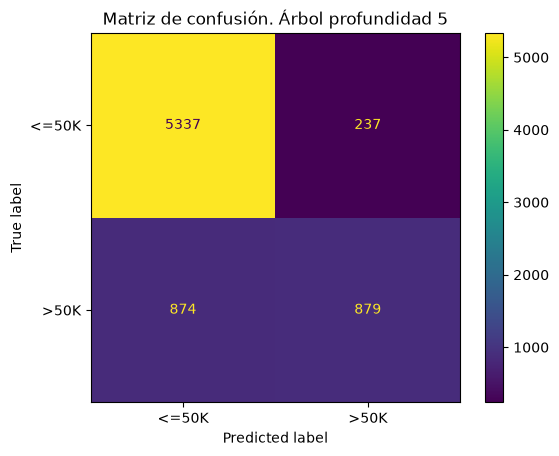

In [11]:
# -----------------------------------------------------------
# 9. Evaluación final en conjunto de prueba
# -----------------------------------------------------------

# El conjunto de prueba se utiliza únicamente después de seleccionar el mejor modelo 
# mediante validación de F1
best_tree_name = "Árbol profundidad 5"
best_tree_model = tree_models[best_tree_name]

y_pred_tree_test = best_tree_model.predict(X_test)
y_prob_tree_test = best_tree_model.predict_proba(X_test)[:, 1]


tree_test_metrics = {

    "Accuracy": accuracy_score(
        y_test,
        y_pred_tree_test
    ),

    "Precision": precision_score(
        y_test,
        y_pred_tree_test
    ),

    "Recall": recall_score(
        y_test,
        y_pred_tree_test
    ),

    "F1": f1_score(
        y_test,
        y_pred_tree_test
    ),

    "AUC-ROC": roc_auc_score(
        y_test,
        y_prob_tree_test
    )
}

print("\nResultados finales en prueba:")

for metric, value in tree_test_metrics.items():
    print(f"{metric}: {value:.4f}")


# -----------------------------------------------------------
# 8. Matriz de confusión del mejor modelo
# -----------------------------------------------------------

matriz_confusion_tree = confusion_matrix(
    y_test,
    y_pred_tree_test
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_tree,
    display_labels=["<=50K", ">50K"]
)

disp.plot()

plt.title(
    f"Matriz de confusión. {best_tree_name}"
)

plt.show()

### Análisis de resultados del modelo seleccionado como ganador

En este caso, el modelo ganador resultó ser el Árbol de Decisión con profundidad máxima de 5. Esta configuración cuenta con un max_depth=5, min_samples_split=2 y min_samples_leaf=1. En términos simples, esto limita la profundidad del árbol a cinco niveles, lo que permite controlar su complejidad y reducir el riesgo de sobreajuste en comparación con un árbol sin restricciones.

Al momento de evaluar el modelo seleccionado sobre el conjunto de prueba, se obtuvo una exactitud de 84.84%, lo que quiere decir que el árbol clasificó correctamente aproximadamente 85 de cada 100 observaciones. Sin embargo, debido al desequilibrio existente entre las clases la exactitud por sí sola no resulta suficiente para valorar el desempeño del modelo, por lo que también es necesario considerar métricas como precision, recall, F1 y AUC-ROC.

Con respecto a la precisión, se obtuvo un valor de 78.76%, lo que significa que, del total de personas que el modelo clasificó como individuos con ingresos superiores a $50K aproximadamente el 79% realmente pertenecía a esta categoría. Este resultado indica que el modelo presenta una cantidad relativamente reducida de falsos positivos. En cuanto al recall, se obtuvo un valor de 50.14%, lo que significa que el modelo logró identificar correctamente únicamente alrededor de la mitad de todas las observaciones que realmente pertenecían a la clase de ingresos superiores a $50K. Esto evidencia una dificultad importante para detectar la clase minoritaria. El F1, que resume el equilibrio entre precision y recall, fue de 0.6128. Este resultado refleja que, aunque el modelo presenta una buena precisión al predecir la clase >50K, su capacidad para recuperar todas las observaciones que realmente pertenecen a esta categoría es limitada. Finalmente, el AUC-ROC de 0.8856 evidencia una buena capacidad general de discriminación, lo que significa que el árbol logra diferenciar razonablemente bien entre individuos con ingresos superiores a $50K y aquellos con ingresos iguales o inferiores a este nivel.

En lo que respecta a la matriz de confusión, se clasificaron correctamente 5337 individuos con ingresos iguales o inferiores a $50K y 879 individuos con ingresos superiores a $50K. Además, se registraron 237 falsos positivo  correspondientes a personas clasificadas como >50K cuando realmente pertenecían a la categoría <=50K y 874 falsos negativos, lo que quiere decir, personas clasificadas como <=50K cuando realmente contaban con ingresos superiores a $50K.

La diferencia entre falsos positivos y falsos negativos es considerable, lo que confirma que su principal limitación se encuentra en la identificación de la clase >50K. En otras palabras, el árbol tiende a ser conservador al asignar una observación a la categoría de mayores ingresos. Así, cuando realiza esta predicción suele acertar, pero deja sin identificar a una proporción importante de las personas que realmente pertenecen a dicha categoría.

En síntesis, el Árbol de Decisión con profundidad máxima de 5 presenta un buen desempeño global especialmente considerando una exactitud cercana al 85% y un AUC-ROC de 0.8856. No obstante, el recall de 50.14% y la elevada cantidad de falsos negativos muestran que todavía existe una limitación importante para identificar individuos con ingresos superiores a $50K. Por esta razón, la evaluación del árbol debe considerar conjuntamente accuracy, precision, recall, F1 y AUC-ROC, y no basarse únicamente en su nivel de exactitud. En la comparación final con los demás modelos del proyecto será importante determinar si algún algoritmo logra mantener niveles similares de accuracy y AUC-ROC, pero mejorar el recall y el F1 de la clase >50K, ya que esto representaría una mejor capacidad para identificar correctamente la clase minoritaria.